In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Patch 
from collections import Counter
import math
from matplotlib.colors import ListedColormap
from pathlib import Path
import scipy.sparse as sp

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
def here():
    try:
        return Path(__file__).resolve().parent   # script file’s folder
    except NameError:
        return Path.cwd().resolve()              # notebook/REPL

processed_data = (here().parents[1] / "2024_Nov" / "Processed_data").resolve()

In [4]:
def get_unscaled_log(adata):
    X_scaled = adata.X
    std = adata.var["std"].to_numpy()

    if sp.issparse(X_scaled):
        X_log1p = (X_scaled @ sp.diags(std)).astype(np.float32)
    else:
        X_log1p = (np.asarray(X_scaled) * std).astype(np.float32)
    return X_log1p

In [5]:
top_n = 10
marker_summary = []
concatenated_actual = pd.DataFrame()
concatenated_predict = pd.DataFrame()

for filename in os.listdir(processed_data):
    if filename.endswith(".h5ad"):
        file_path = os.path.join(processed_data, filename)
        anndata = sc.read_h5ad(file_path)
        organ = filename.split("_")[0]
        print(f"Processing {organ} =======================================================")
        celltypes = np.unique(anndata.obs["cell_ontology_class"])
        
        for celltype in celltypes:
            celltype_object = anndata[anndata.obs["cell_ontology_class"] == celltype]
            celltype_object.layers["log1p_unscaled"] = get_unscaled_log(celltype_object)
            sc.tl.rank_genes_groups(
                celltype_object,
                groupby="age",
                method="wilcoxon",
                use_raw=False,
                layer="log1p_unscaled"   # <- log-normalized values (unscaled)
            )
            age_df = sc.get.rank_genes_groups_df(celltype_object, group=None)
            age_df = age_df[age_df["pvals_adj"] < 0.05]
            age_df = (
                age_df.sort_values(by=["logfoldchanges", "pvals_adj"], ascending=[False, True])
                      .groupby(["group"])
                      .head(top_n)
            )
            experiment = f"{organ}_{celltype}"
            if experiment == "Kidney_kidney loop of Henle thick ascending limb epithelial cell":
                experiment = "Kidney TAL epith cell"
            elif experiment == "Bone-Marrow_megakaryocyte-erythroid progenitor cell":
                experiment = "Bone-Marrow MEP cell"
            elif experiment == "Kidney_kidney proximal convoluted tubule epithelial cell":
                experiment = "Kidney_PCT_epith cell"
            age_df["experiment"] = experiment
            concatenated_actual = pd.concat([concatenated_actual, age_df])
            
            sc.tl.rank_genes_groups(
                celltype_object,
                groupby="pred_age",
                method="wilcoxon",
                use_raw=False,
                layer="log1p_unscaled"   # <- log-normalized values (unscaled)
            )
            predict_age_df = sc.get.rank_genes_groups_df(celltype_object, group=None)
            predict_age_df = predict_age_df[predict_age_df["pvals_adj"] < 0.05]
            predict_age_df = (
                predict_age_df.sort_values(by=["logfoldchanges", "pvals_adj"], ascending=[False, True])
                              .groupby(["group"])
                              .head(top_n)
            )
            predict_age_df["experiment"] = experiment
            concatenated_predict = pd.concat([concatenated_predict, predict_age_df])

Processing Limb-Muscle =======================================================
Processing Brain =======================================================
Processing Heart =======================================================
Processing Lung =======================================================
Processing Bladder =======================================================
Processing Liver =======================================================
Processing Kidney =======================================================
Processing Bone-Marrow =======================================================


In [6]:
concatenated_actual.to_csv("./DEG_by_month/DEG_actual_significant_markers.csv")
concatenated_predict.to_csv("./DEG_by_month/DEG_actual_significant_markers.csv")

In [7]:
concatenated_actual.shape, concatenated_predict.shape

((1350, 7), (1288, 7))

In [8]:
age_groups = sorted(np.unique(concatenated_predict["group"]), key=lambda x: int(x.strip("m")))

# Build global top-gene set from predicted only
all_top_genes = set()
for age in age_groups:
    data_pred = concatenated_predict[concatenated_predict["group"] == age]
    mat_pred = pd.crosstab(data_pred["names"], data_pred["experiment"])
    top_pred = mat_pred.sum(axis=1).sort_values(ascending=False).head(20).index
    all_top_genes.update(top_pred)
all_experiments = sorted(concatenated_actual["experiment"].unique())

In [9]:
len(all_top_genes)

93

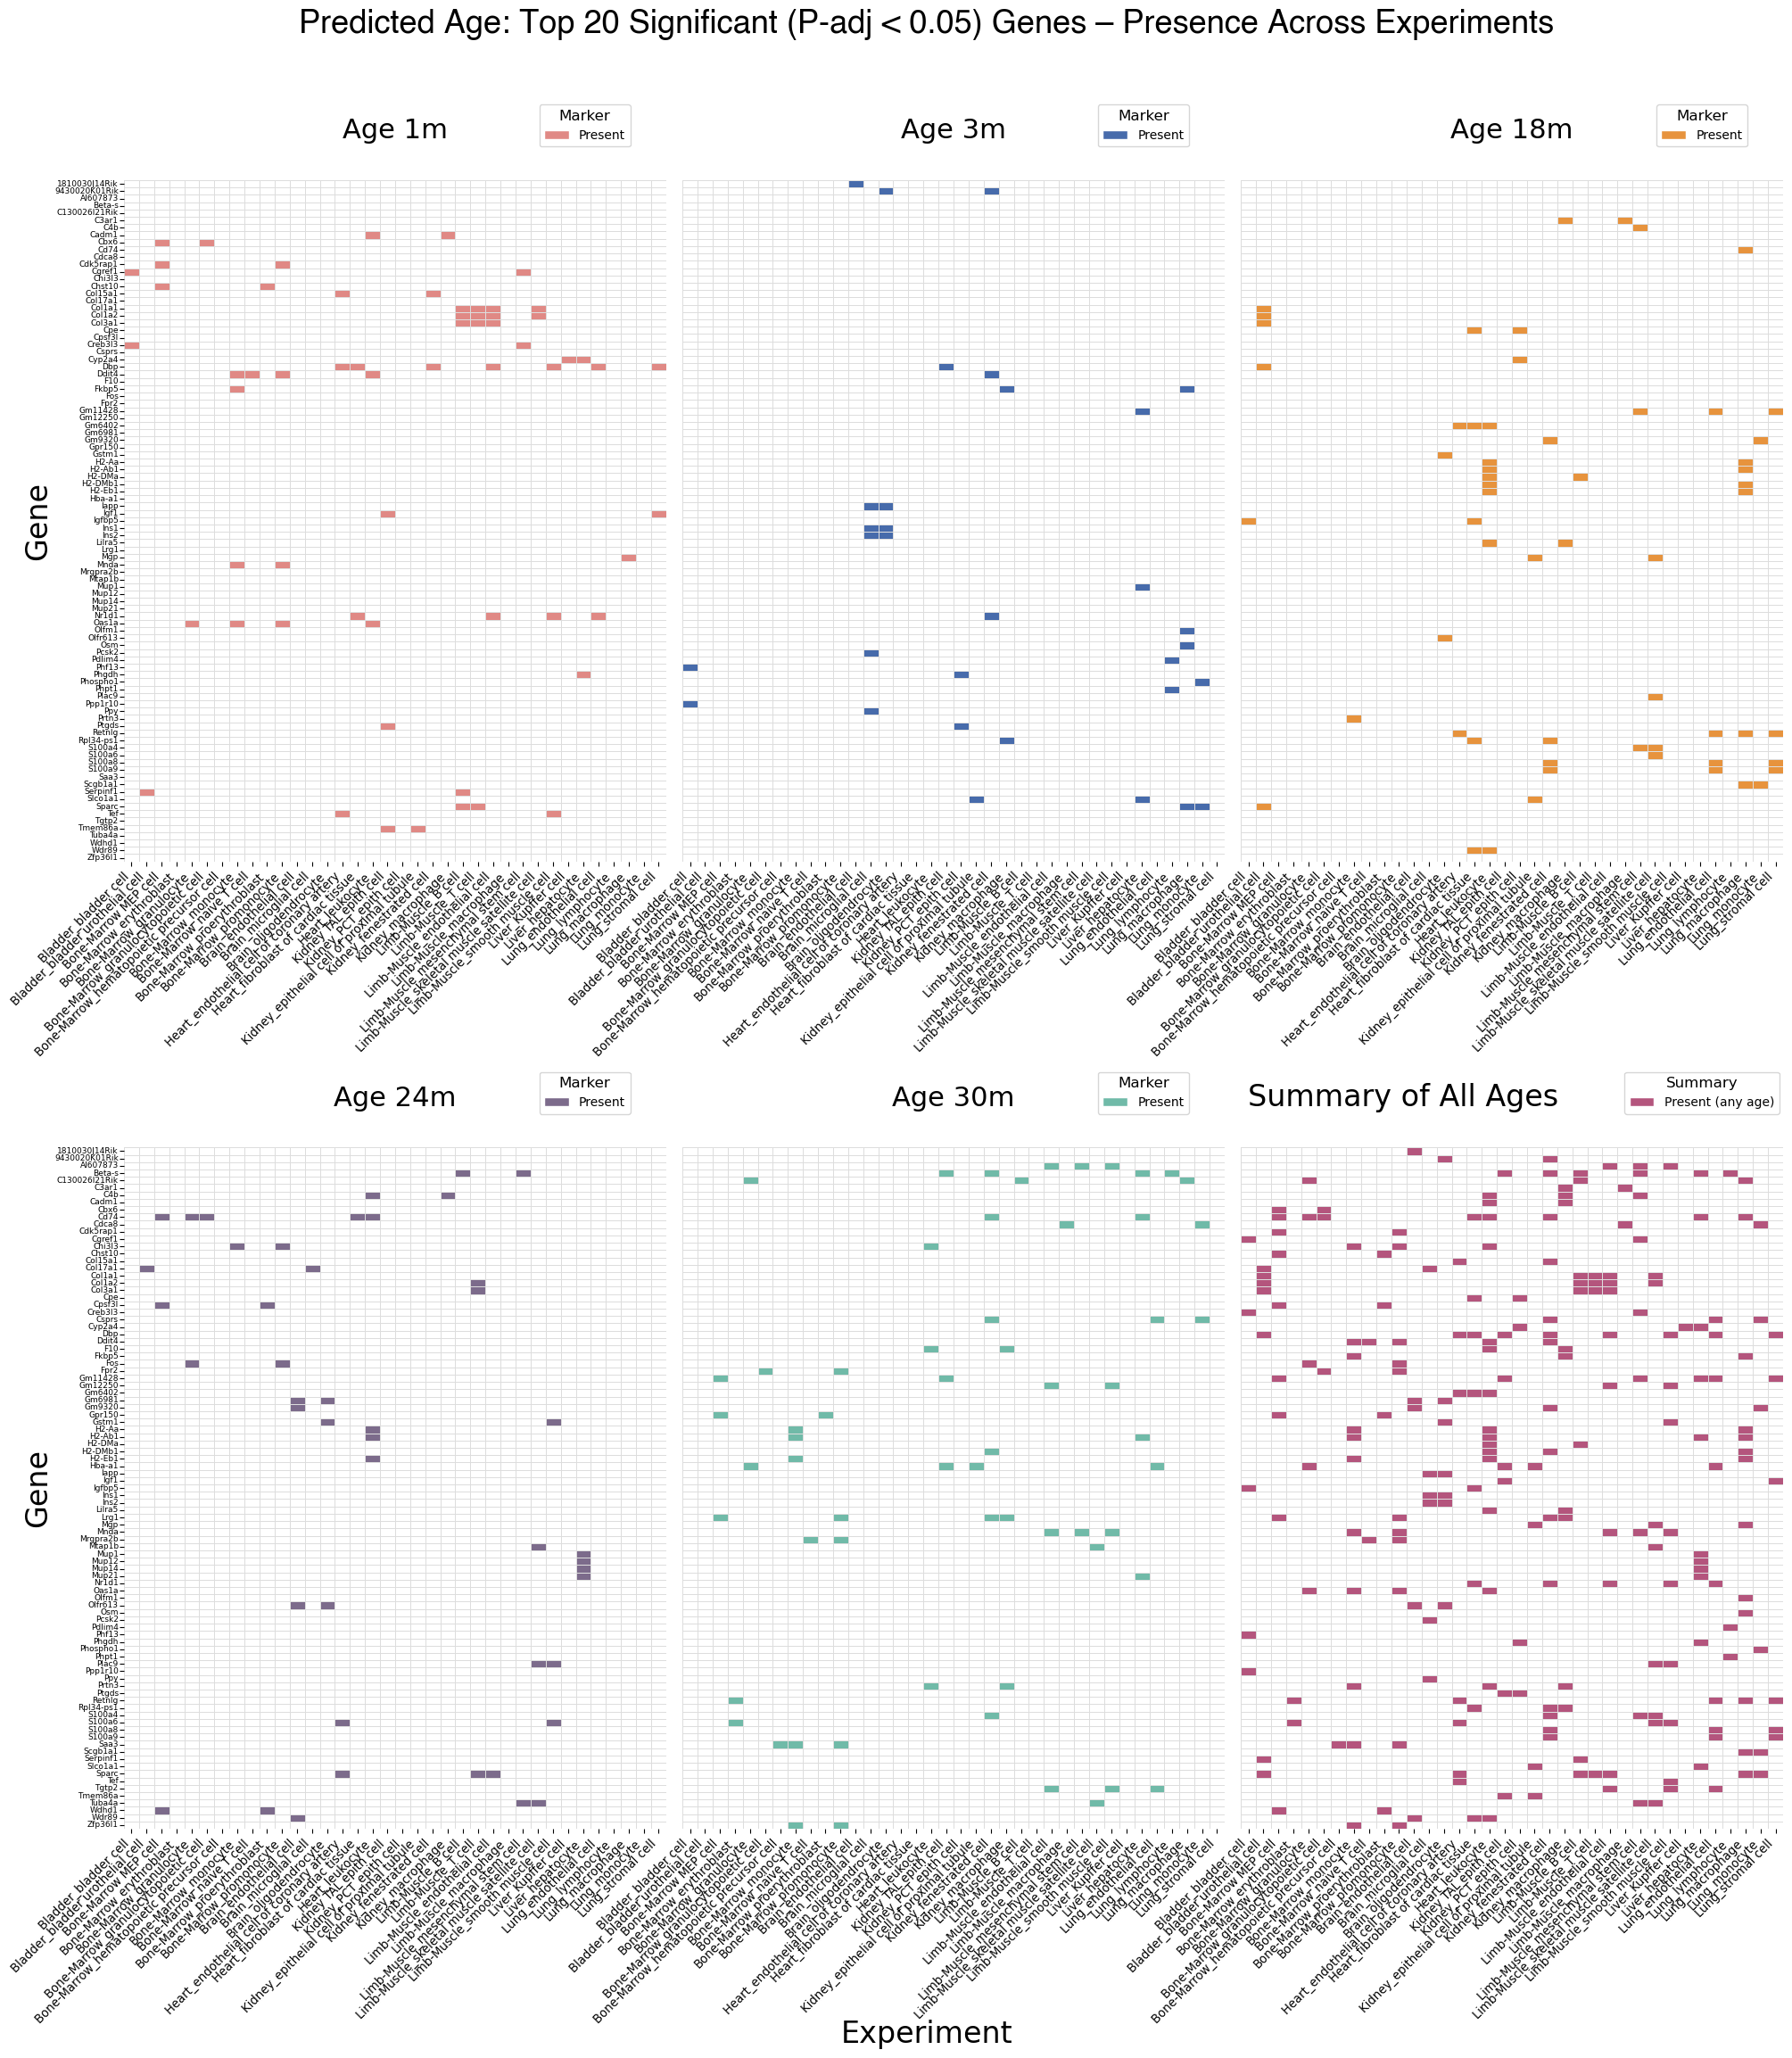

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(24, 24), gridspec_kw={'wspace': 0.03, 'hspace': 0.42})  # wider/taller canvas for 2 rows
axes = axes.flatten()

# One color per age for "present"
color_codes = ["#E08985", "#476BAB", "#E7933D", "#7C6B8B", "#70BAA8"]  # extend if >5 ages

merged_presence_matrices = []

for i, age in enumerate(age_groups):
    data = concatenated_predict[concatenated_predict["group"] == age]
    predict_presence_matrix = pd.crosstab(data["names"], data["experiment"], dropna=False)

    plot_matrix = (predict_presence_matrix.gt(0).astype(int)
        .reindex(index=all_top_genes, fill_value=0)
        .reindex(columns=all_experiments, fill_value=0))

    for gene in all_top_genes:
        if gene not in plot_matrix.index:
            plot_matrix.loc[gene] = 0
    plot_matrix = plot_matrix.sort_index()

    merged_presence_matrices.append(plot_matrix.copy())

    # colormap: 0 = white, 1 = age-specific color
    cmap = ListedColormap(["white", color_codes[i % len(color_codes)]])

    show_y = i in (0, 3)
    
    sns.heatmap(
        plot_matrix,
        cmap=cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='#DDDDDD',
        xticklabels=True,
        yticklabels=show_y,
        ax=axes[i],
        vmin=0, vmax=1
    )

    if not show_y:
        axes[i].set_ylabel("")
        axes[i].tick_params(axis='y', length=0)
    else:
        axes[i].tick_params(axis='y', labelsize=6.5)

    axes[i].set_title(f"Age {age}", fontsize=22, y=1.05)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
        label.set_fontsize(9.5)

    handles = [Patch(facecolor=color_codes[i % len(color_codes)], edgecolor='white', label="Present")]
    axes[i].legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.85, 1.12),
        frameon=True,
        fontsize=10,
        title="Marker",
        title_fontsize=12
    )

# === Summary panel (axes[5]) ===
combined_matrix = pd.concat(merged_presence_matrices)
# Any presence across experiments becomes 1; then aggregate across ages by max
combined_binary = combined_matrix.gt(0).astype(int).groupby(combined_matrix.index).max()

merged_cmap = ListedColormap(["white", "#B4557D"])

sns.heatmap(
    combined_binary,
    cmap=merged_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    xticklabels=True,
    yticklabels=False,   # keep summary uncluttered
    ax=axes[5],
    vmin=0, vmax=1
)

summary_handles = [Patch(facecolor="#B4557D", edgecolor='white', label="Present (any age)")]
axes[5].legend(
    handles=summary_handles,
    loc='upper center',
    bbox_to_anchor=(0.85, 1.12),
    frameon=True,
    fontsize=10,
    title="Summary",
    title_fontsize=12
)

axes[5].set_title("Summary of All Ages", fontsize=24, x = 0.3, y=1.05)
axes[5].set_xlabel("")
axes[5].set_ylabel("")

for label in axes[5].get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')
    label.set_fontsize(9.5)

for i in (0, 3):
    axes[i].set_ylabel('Gene', fontsize=24)
    axes[i].yaxis.labelpad = 1        # keep it very close to the spine
    axes[i].tick_params(axis='y', pad=1)

fig.text(0.5, 0.01, 'Experiment', ha='center', fontsize=24)

plt.suptitle(
    "Predicted Age: Top 20 Significant (P-adj < 0.05) Genes – Presence Across Experiments",
    fontsize=26, fontname="helvetica", y=0.96
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("./Figures/Figure 6.png", bbox_inches='tight', dpi=600)
plt.show()

In [11]:
combined_binary.to_csv("./DEG_by_month/predicted_only_gene_list.csv")

## compare actual vs predicted 

In [12]:
age_groups = sorted(np.unique(concatenated_actual["group"]), key=lambda x: int(x.strip("m")))

all_top_genes = set()
for age in age_groups:
    data_actual = concatenated_actual[concatenated_actual["group"] == age]
    mat_actual = pd.crosstab(data_actual["names"], data_actual["experiment"])
    top_actual = mat_actual.sum(axis=1).sort_values(ascending=False).head(20).index

    data_pred = concatenated_predict[concatenated_predict["group"] == age]
    mat_pred = pd.crosstab(data_pred["names"], data_pred["experiment"])
    top_pred = mat_pred.sum(axis=1).sort_values(ascending=False).head(20).index

    all_top_genes.update(top_actual)
    all_top_genes.update(top_pred)

# Final consistent gene list (sorted for consistency)
shared_top_genes = sorted(all_top_genes)
print(len(shared_top_genes))

all_experiments = sorted(concatenated_actual["experiment"].unique())

144


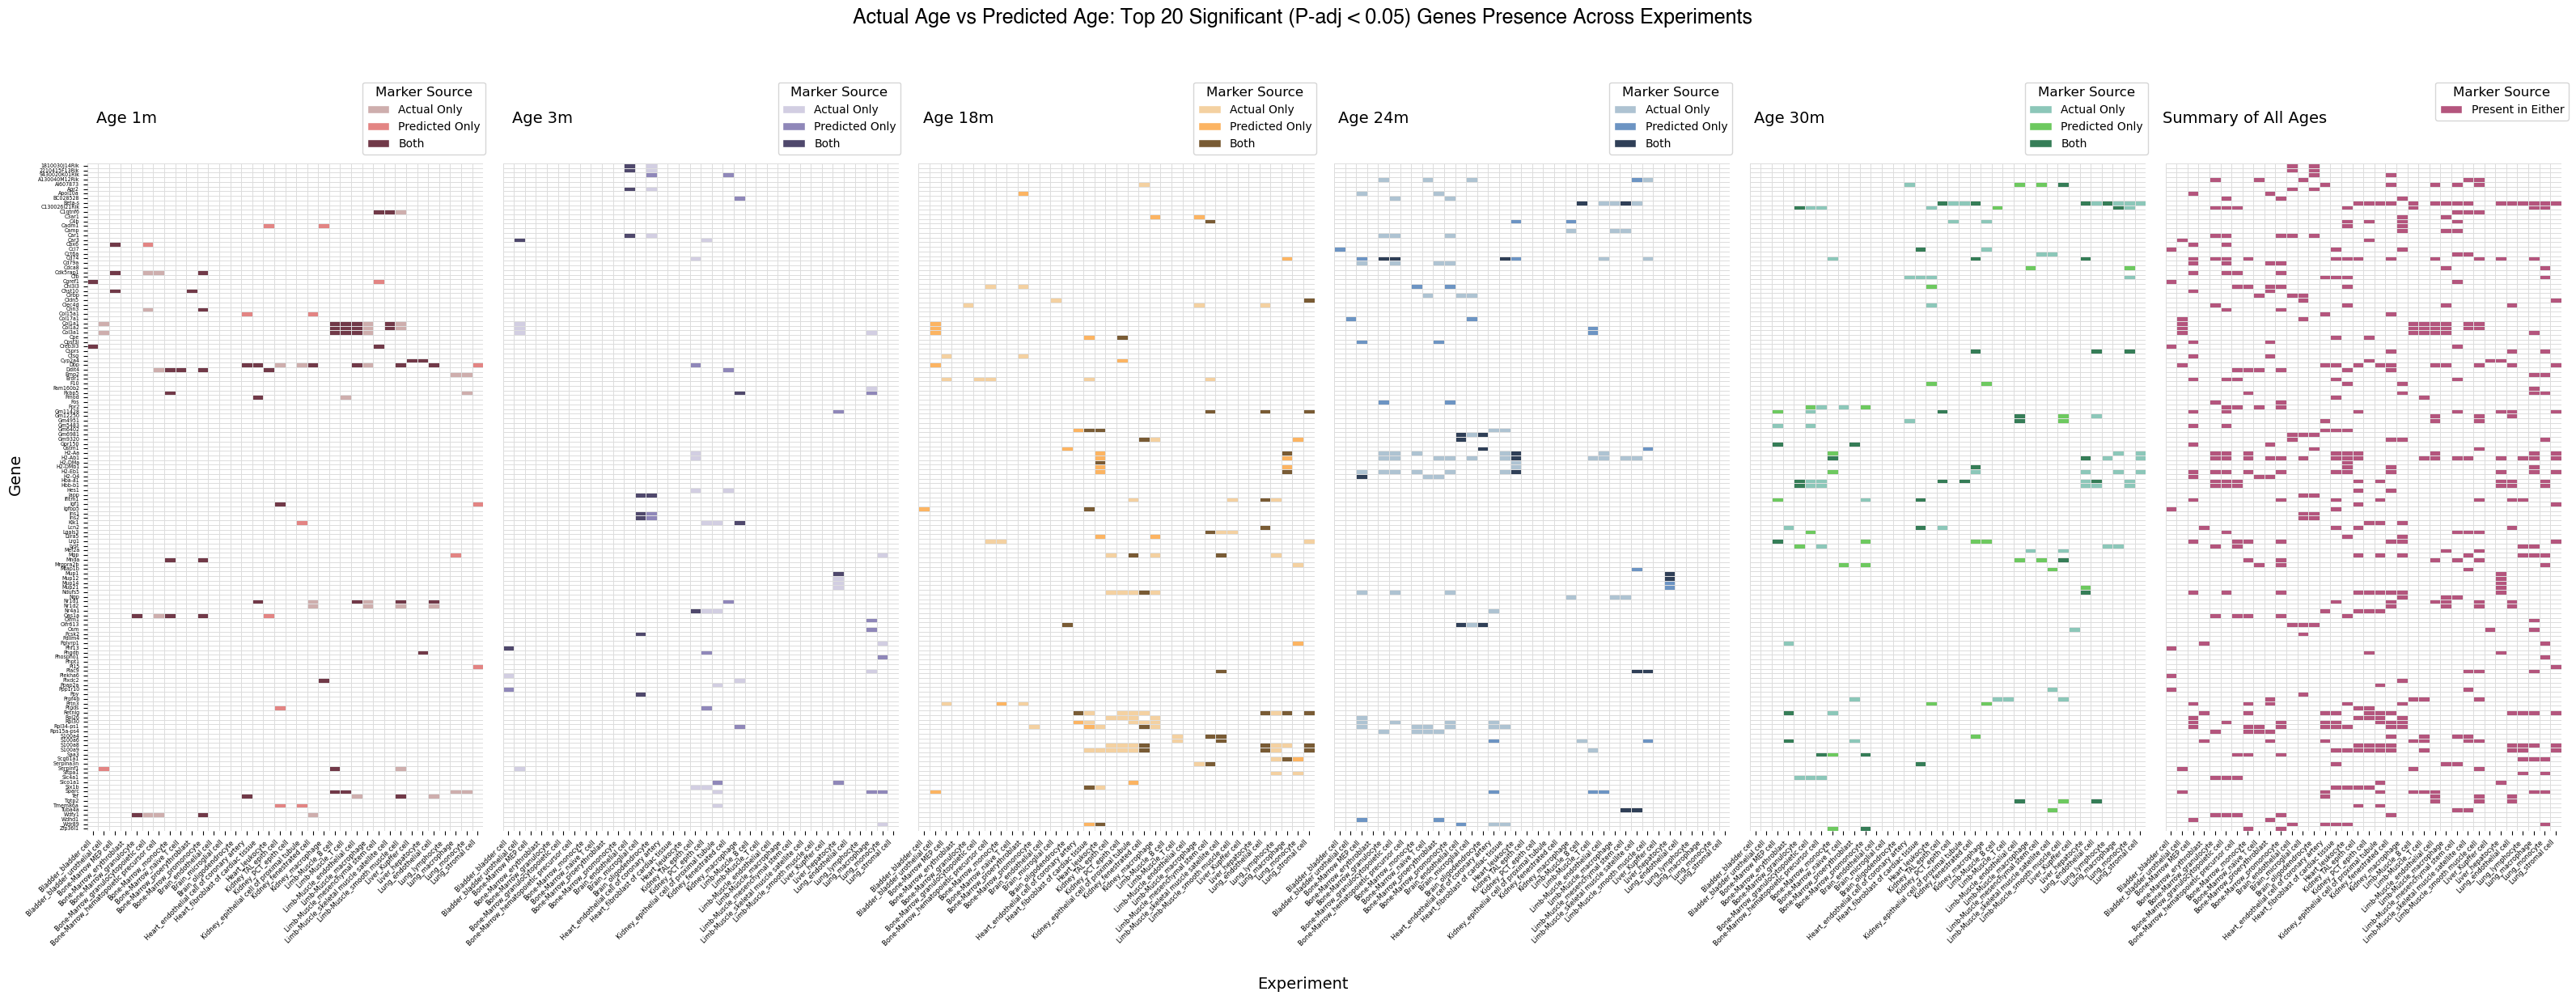

In [13]:
merged_presence_matrices = []

fig, axes = plt.subplots(1, 6, figsize=(32, 12))  # 2 rows x 3 columns
plt.subplots_adjust(hspace=0.7)  # Increase to 0.6 or 0.7 if needed
axes = axes.flatten()
color_codes = ["#E08985", "#476BAB", "#E7933D", "#7C6B8B", "#70BAA8"]
for i, age in enumerate(age_groups):
    data = concatenated_actual[concatenated_actual["group"] == age]
    actual_presence_matrix = pd.crosstab(data["names"], data["experiment"])
    actual_presence_matrix["sum"] = actual_presence_matrix.sum(axis=1)
    actual_presence_matrix = actual_presence_matrix.sort_values("sum", ascending=False).drop(columns = "sum")
    actual_top_genes = actual_presence_matrix.head(20).index

    # predicted summary
    data = concatenated_predict[concatenated_predict["group"] == age]
    predict_presence_matrix = pd.crosstab(data["names"], data["experiment"])
    predict_presence_matrix["sum"] = predict_presence_matrix.sum(axis=1)
    predict_presence_matrix = predict_presence_matrix.sort_values("sum", ascending=False).drop(columns = "sum")
    predicted_top_genes = predict_presence_matrix.head(20).index
    
    top_genes = shared_top_genes
    
    # Convert to boolean .gt() == >0
    actual_bool = actual_presence_matrix.gt(0)
    predicted_bool = predict_presence_matrix.gt(0)
    
    # Fill missing genes with 0
    for gene in top_genes:
        if gene not in actual_bool.index:
            actual_bool.loc[gene] = False
        if gene not in predicted_bool.index:
            predicted_bool.loc[gene] = False
    

    # 0 = none, 1 = actual only, 2 = predicted only, 3 = both
    plot_matrix = actual_bool.astype(int) * 1 + predicted_bool.astype(int) * 2
    plot_matrix = plot_matrix.loc[top_genes]
    plot_matrix["sum"] = plot_matrix.sum(axis = 1)
    plot_matrix = plot_matrix.sort_values("sum", ascending=False).drop(columns = "sum")
    plot_matrix = plot_matrix.reindex(index=shared_top_genes, columns=all_experiments, fill_value=0)
    merged_presence_matrices.append(plot_matrix.copy())

    # Custom colormap per age group
    color_triplet = [
        "white",  # 0 = not present
        ["#CEAEAD", "#D2CEE2", "#F4D1A1", "#AEC3D2", "#70BAA8CC"][i],  # 1 = actual only
        ["#E38483", "#8F87B9", "#FCB462", "#6C94C3", "#6DC95F"][i],  # 2 = predicted only
        ["#713948", "#4F486C", "#795B34", "#2F3F57", "#357D57"][i],  # 3 = both
    ]
    cmap = ListedColormap(color_triplet)

    sns.heatmap(
        plot_matrix,
        cmap=cmap,
        cbar=False,
        linewidths=0.5,
        linecolor='#DDDDDD',
        xticklabels=True,
        yticklabels=True,
        ax=axes[i],
        vmin=0, vmax=3  # needed to fix colormap bounds
    )
    
    # Show y-axis only for the first subplot
    if i == 0:
        axes[i].tick_params(axis='y', labelsize=4.5)
    else:
        axes[i].set_ylabel("")
        axes[i].set_yticklabels([])  # hide y-axis labels for all others
        axes[i].tick_params(axis='y', length=0)  # hide tick lines
    
    axes[i].set_title(f"Age {age}", fontsize=14, x=0.1, y=1.05)
    axes[i].set_xlabel("")  # remove per-subplot x label
    axes[i].set_ylabel("")  # remove per-subplot y label

    for label in axes[i].get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')  # aligns rotated labels better
        label.set_fontsize(6)  # reduce font size if labels are long
    
    # Legend labels and per-age-group color codes
    legend_labels = ["Actual Only", "Predicted Only", "Both"]
    legend_colors = [
        color_triplet[1],  # actual only (lighter)
        color_triplet[2],  # predicted only
        color_triplet[3],  # both
    ]

    # Create and add a legend for this subplot
    handles = [Patch(facecolor=legend_colors[i], edgecolor='white', label=legend_labels[i]) for i in range(3)]
    axes[i].legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.85, 1.13),  # place outside top-right of subplot
        frameon=True,
        fontsize=10,
        title="Marker Source",
        title_fontsize=12
    )
    
    
# axes[5].axis('off')
## axes[5] will be a summary graph
combined_matrix = pd.concat(merged_presence_matrices)
# Any non-zero becomes 1
combined_binary = combined_matrix.gt(0).astype(int)
combined_binary = combined_binary.groupby(combined_binary.index).max()
merged_cmap = ListedColormap(["white", "#B4557D"])

sns.heatmap(
    combined_binary,
    cmap=merged_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="#DDDDDD",
    xticklabels=True,
    yticklabels=True,
    ax=axes[5],
    vmin=0, vmax=1
)

# Add legend to the summary plot (axes[5])
summary_legend_labels = ["Present in Either"]
summary_legend_colors = ["#B4557D"]
summary_handles = [Patch(facecolor=color, edgecolor='white', label=label)
                   for color, label in zip(summary_legend_colors, summary_legend_labels)]

axes[5].legend(
    handles=summary_handles,
    loc='upper center',
    bbox_to_anchor=(0.85, 1.13),  # adjust as needed for alignment
    frameon=True,
    fontsize=10,
    title="Marker Source",
    title_fontsize=12
)

axes[5].set_title("Summary of All Ages", fontsize=14, x=0.2, y=1.05)
axes[5].set_ylabel("")
axes[5].set_xlabel("")
axes[5].set_yticklabels([])  # hide y-axis labels for 5
axes[5].tick_params(axis='y', length=0)  # hide tick lines

for label in axes[5].get_xticklabels():
    label.set_rotation(45)
    label.set_fontsize(6)
    label.set_horizontalalignment('right')
for label in axes[5].get_yticklabels():
    label.set_fontsize(8)


plt.suptitle("Actual Age vs Predicted Age: Top 20 Significant (P-adj < 0.05) Genes Presence Across Experiments", fontsize=18, fontname="helvetica", y=0.98)
fig.text(0.5, -0.03, 'Experiment', ha='center', fontsize=14)

fig.text(0, 0.5, 'Gene', va='center', rotation='vertical', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.82, wspace=0.05, hspace=0.3) ## adjusting the blank space in between
plt.savefig("./Figures/actual_vs_predicted_age_combined_panel.png", bbox_inches='tight', dpi=600)
plt.show()
    

In [14]:
combined_binary.to_csv("./DEG_by_month/actual_vs_predicted_combined_gene_list.csv")

## Pie chart

In [15]:
classifications = pd.read_csv("./DEG_by_month/Supplementary Table 2.csv")
classifications

,Gene,Category
0,Pdlim4,Cytoskeleton
1,Cgref1,Calcium-binding / signaling
2,Wdhd1,Cell cycle
3,Cdca8,Cell cycle
4,Fkbp5,Chaperone protein
...,...,...
88,Phf13,Transcription / stress
89,Tef,Transcription / stress
90,Zfp36l1,Transcription / stress
91,Slco1a1,Transporter (solute carrier)


In [16]:
class_sum = np.sum(pd.crosstab(classifications["Gene"], classifications["Category"]), axis = 0)
df = (
    class_sum.astype(int)
             .sort_values(ascending=True)
             .rename_axis("Category")
             .reset_index(name="count")
)
df["percent"] = df["count"] / df["count"].sum() * 100

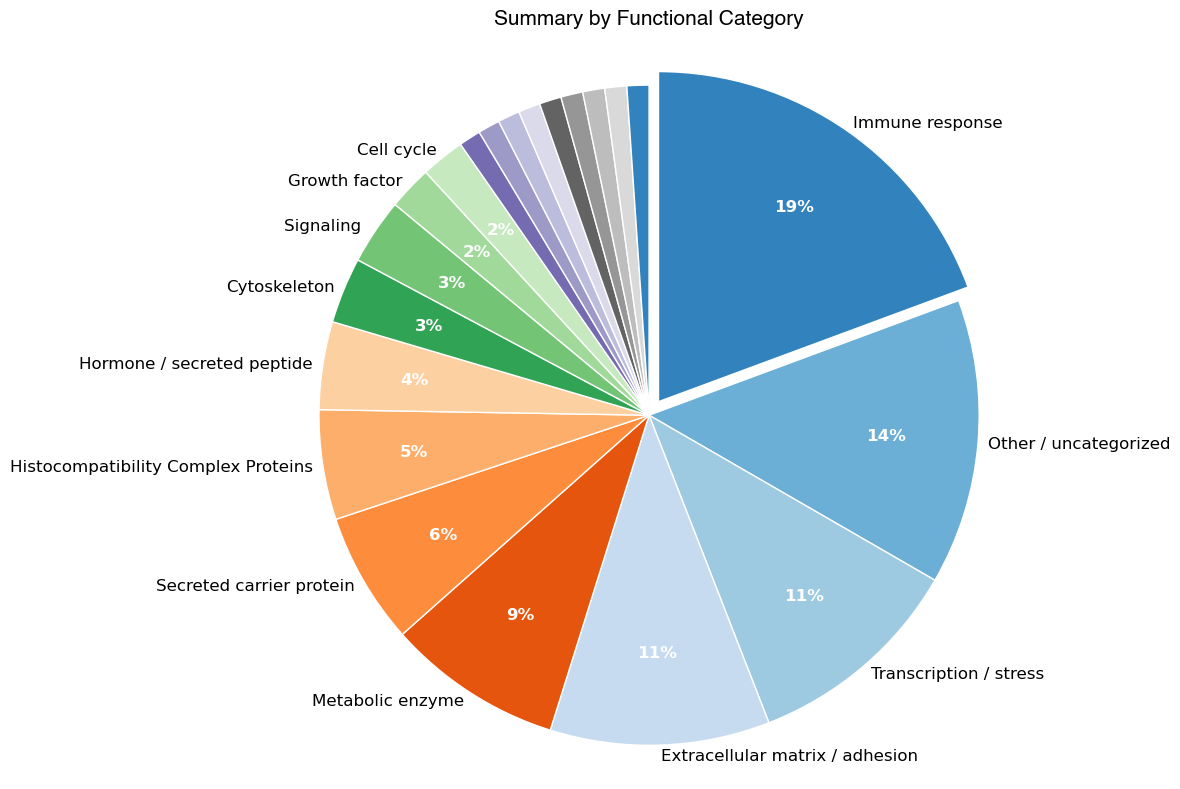

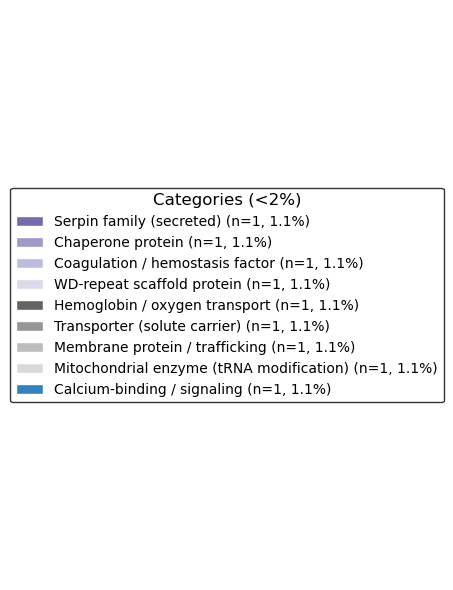

In [17]:
threshold = 2.0  # % cutoff for labeling on the pie

d = df.copy().sort_values("percent", ascending=False).reset_index(drop=True)
explode = [0.05 if i == 0 else 0 for i in range(len(d))]

colors = plt.cm.tab20c.colors[:len(d)]

# Create main pie chart figure (without legend)
fig, ax = plt.subplots(figsize=(10, 8))

def autopct_fmt(pct):
    return f"{pct:.0f}%" if pct >= threshold else ""

pie_labels = [cat if pct >= threshold else "" 
              for cat, pct in zip(d["Category"], d["percent"])]

wedges, texts, autotexts = ax.pie(
    d["percent"],
    labels=pie_labels,
    autopct=autopct_fmt,
    startangle=90,
    counterclock=False,
    explode=explode,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    labeldistance=1.03,   
    pctdistance=0.72      
)

for t in texts:
    t.set_fontsize(12)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
    at.set_weight("bold")

ax.set_title("Summary by Functional Category", fontsize=15, fontname="helvetica", pad=10)
ax.axis("equal")
plt.tight_layout()  
plt.savefig("./Figures/DEG_Classification_pie_no_legend.png", dpi=600, bbox_inches="tight")
plt.show()

# Create separate legend figure
mask_small = d["percent"] < threshold
small_idx = [i for i, m in enumerate(mask_small) if m]

if len(small_idx) > 0:  # Only create legend if there are small categories
    legend_handles = [wedges[i] for i in small_idx]
    legend_labels = [f"{d.loc[i,'Category']} (n={int(d.loc[i,'count'])}, {d.loc[i,'percent']:.1f}%)"
                    for i in small_idx]
    
    # Create figure for legend only
    fig_legend = plt.figure(figsize=(5, 6))
    ax_legend = fig_legend.add_subplot(111)
    ax_legend.axis('off')
    
    # Create the legend
    legend = ax_legend.legend(
        legend_handles, legend_labels,
        title=f"Categories (<{int(threshold)}%)",
        title_fontsize=12,
        fontsize=10,
        loc="center",
        frameon=True,
        fancybox=True,
        shadow=False
    )
    
    # Style the legend
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('black')
    legend.get_frame().set_linewidth(1)
    
    # Save legend figure
    plt.tight_layout()
    plt.savefig("./Figures/DEG_Classification_pie_legend_only.png", dpi=600, bbox_inches="tight")
    plt.show()

## Compare with correlation lists

In [18]:
cor_classifications = pd.read_csv("./Supplementary Table 1.csv")
cor_classifications

,Gene,Category
0,Ppia,Housekeeping
1,Pfn1,Cytoskeleton
2,Tmsb4x,Cytoskeleton
3,Tmsb10,Cytoskeleton
4,Actb,Cytoskeleton
...,...,...
95,Ptma,Transcription / stress
96,Ddx5,Transcription / stress
97,Rbm3,Transcription / stress
98,Eef2,Transcription / stress


In [19]:
cor_classifications["Study"] = "Correlation Study"
cor_classifications

,Gene,Category,Study
0,Ppia,Housekeeping,Correlation Study
1,Pfn1,Cytoskeleton,Correlation Study
2,Tmsb4x,Cytoskeleton,Correlation Study
3,Tmsb10,Cytoskeleton,Correlation Study
4,Actb,Cytoskeleton,Correlation Study
...,...,...,...
95,Ptma,Transcription / stress,Correlation Study
96,Ddx5,Transcription / stress,Correlation Study
97,Rbm3,Transcription / stress,Correlation Study
98,Eef2,Transcription / stress,Correlation Study


In [20]:
classifications["Study"] = "DEG Study"
classifications

,Gene,Category,Study
0,Pdlim4,Cytoskeleton,DEG Study
1,Cgref1,Calcium-binding / signaling,DEG Study
2,Wdhd1,Cell cycle,DEG Study
3,Cdca8,Cell cycle,DEG Study
4,Fkbp5,Chaperone protein,DEG Study
...,...,...,...
88,Phf13,Transcription / stress,DEG Study
89,Tef,Transcription / stress,DEG Study
90,Zfp36l1,Transcription / stress,DEG Study
91,Slco1a1,Transporter (solute carrier),DEG Study


In [21]:
comp = pd.concat([cor_classifications, classifications])
comp

,Gene,Category,Study
0,Ppia,Housekeeping,Correlation Study
1,Pfn1,Cytoskeleton,Correlation Study
2,Tmsb4x,Cytoskeleton,Correlation Study
3,Tmsb10,Cytoskeleton,Correlation Study
4,Actb,Cytoskeleton,Correlation Study
...,...,...,...
88,Phf13,Transcription / stress,DEG Study
89,Tef,Transcription / stress,DEG Study
90,Zfp36l1,Transcription / stress,DEG Study
91,Slco1a1,Transporter (solute carrier),DEG Study


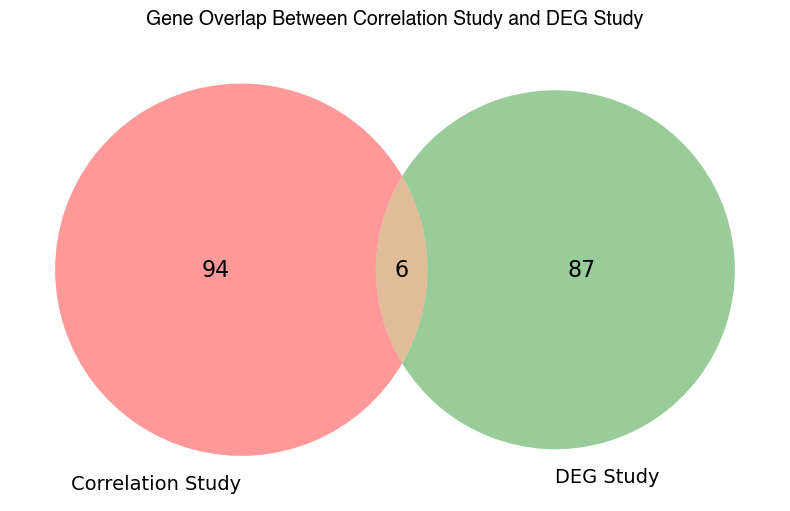

In [22]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

def create_venn_diagram(df, study1, study2, gene_col="Gene", study_col="Study"):
    
    # Get genes for each study
    genes_study1 = set(df[df[study_col] == study1][gene_col].dropna().astype(str))
    genes_study2 = set(df[df[study_col] == study2][gene_col].dropna().astype(str))
    
    # Calculate overlap statistics
    overlap = genes_study1.intersection(genes_study2)
    only_study1 = genes_study1 - genes_study2
    only_study2 = genes_study2 - genes_study1
    
    # Create Venn diagram
    fig, ax = plt.subplots(figsize=(8, 6))
    
    venn2([genes_study1, genes_study2], 
          set_labels=(study1, study2),
          ax=ax)
    
    # Customize the plot
    ax.set_title(f"Gene Overlap Between {study1} and {study2}", 
                fontsize=14, fontname="helvetica", pad=10)
    
    # Adjust label sizes to be smaller and more proportional
    for text in ax.texts:
        if text.get_text() in [study1, study2]:
            text.set_fontsize(14)  
        else:
            text.set_fontsize(16)  
    
    plt.tight_layout()
    fig.savefig("./Figures/Overlap_results.png", dpi=600, bbox_inches="tight")
    plt.show()
    
    return {
        'study1_genes': genes_study1,
        'study2_genes': genes_study2,
        'overlap_genes': overlap,
        'only_study1': only_study1,
        'only_study2': only_study2
    }

# Create the Venn diagram
venn_results = create_venn_diagram(comp, 
                                 study1="Correlation Study", 
                                 study2="DEG Study",
                                 gene_col="Gene", 
                                 study_col="Study")


In [23]:
hits = comp.loc[comp["Gene"].isin(venn_results["overlap_genes"]), ["Gene","Category"]]
hits = hits.assign(
    Gene=hits["Gene"].astype(str).str.strip(),
    Category=hits["Category"].astype(str).str.strip()
)

table = (hits.groupby("Gene", as_index=False)
             .agg(Category=("Category", lambda s: "; ".join(pd.unique(s))))
             .sort_values(["Category","Gene"], kind="stable")
             .reset_index(drop=True))

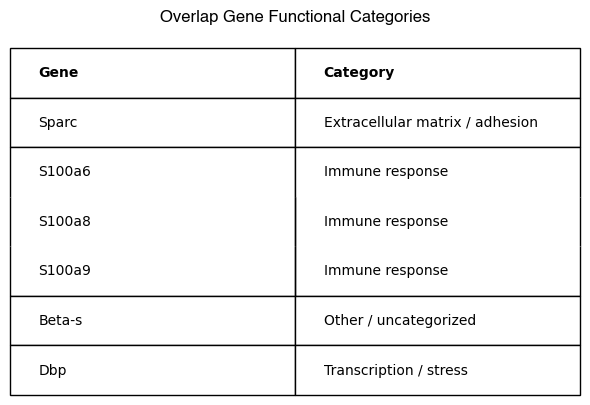

In [24]:
from matplotlib.font_manager import FontProperties
header_fp = FontProperties(family="DejaVu Sans", weight="bold")
fp = FontProperties(family="DejaVu Sans")
table = table[["Gene","Category"]]

rows = len(table)
fig_w = 6
row_h = 0.5
fig_h = max(1.0, 1 + rows*row_h)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis("off")

tab = ax.table(cellText=table.values,
               colLabels=table.columns,
               loc="center", cellLoc="left", colLoc="left",
               bbox=[0, 0, 1, 0.95])

tab.auto_set_font_size(False)
tab.set_fontsize(16)
tab.scale(1, 1.15)

for (r, c), cell in tab.get_celld().items():
    cell.visible_edges = "closed"
    cell.get_text().set_fontproperties(fp)  

for c in range(2):  # bold header
    tab[(0, c)].get_text().set_fontproperties(header_fp)

n_cols = 2
for i in range(1, rows):  # compare data row i-1 with i
    if table.iloc[i, 1] == table.iloc[i-1, 1]:  # same Category
        for c in range(n_cols):
            # remove the shared border between the two rows:
            # drop bottom edge of previous row's cells
            tab[(i, c)].visible_edges = tab[(i, c)].visible_edges.replace("B", "")
            # drop top edge of current row's cells
            tab[(i+1, c)].visible_edges = tab[(i+1, c)].visible_edges.replace("T", "")

plt.title("Overlap Gene Functional Categories", fontsize = 12, fontname="helvetica")
plt.tight_layout()
fig.subplots_adjust(top=0.95)
plt.savefig("./Figures/overlap_genes_table.png", bbox_inches="tight", dpi=600)